# Chunk cluster visualization

Visualizes the HDBSCAN clusters computed over a worksheet's chunk embeddings (stored in `database.sqlite`).

- PCA to 2D (numpy), with optional t-SNE if scikit-learn is installed.
- Chunks colored by `cluster_index`; HDBSCAN noise (NULL cluster) shown in grey.
- A position-by-cluster view shows how topics band along the document.

> If everything looks like one grey blob, the worksheet predates the clustering fix. Delete its chunks and re-run **Process files**, which now embeds and clusters at ingestion time.


In [3]:
import importlib.util

from pathlib import Path



missing = [m for m in ("numpy", "matplotlib") if importlib.util.find_spec(m) is None]

if missing:

    raise SystemExit(f"Missing packages: {missing}. Install with: python3 -m pip install numpy matplotlib")



import sqlite3

import os

import re

import struct

from collections import Counter, defaultdict



import numpy as np

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

from matplotlib.lines import Line2D



plt.rcParams["figure.dpi"] = 110

print("setup ok")



setup ok


In [4]:
# --- database ---

db_path = os.environ.get("WORXHEET_DB_PATH", str(Path.home() / "Library/Application Support/com.worxheet/database.sqlite"))

if not Path(db_path).exists():

    raise SystemExit(f"database not found at {db_path}; set WORXHEET_DB_PATH")


con = sqlite3.connect(db_path)



worksheets = con.execute("SELECT id, name FROM worksheets ORDER BY created_at").fetchall()

for wid, name in worksheets:

    print(f"worksheet: {wid}  ({name})")

if not worksheets:

    raise SystemExit("no worksheets in database")

wid = os.environ.get("WORXHEET_WORKSHEET_ID") or worksheets[0][0]



worksheet: 01KZSAYTSB2C0V2P1KE7K9T0FY  (Untitled Worksheet)


In [5]:
# --- load chunks + embeddings ---

rows = con.execute(

    "SELECT position, text, cluster_index, embedding FROM chunks "

    "WHERE worksheet_id = ? AND embedding IS NOT NULL ORDER BY position",

    (wid,),

).fetchall()

if not rows:

    raise SystemExit("no embedded chunks for this worksheet")



positions = np.array([r[0] for r in rows])

texts = [r[1] for r in rows]

labels = np.array([r[2] if r[2] is not None else -1 for r in rows])

vectors = np.array([struct.unpack("<384f", r[3]) for r in rows])



n_noise = int((labels == -1).sum())

present = sorted({int(l) for l in labels if l >= 0})

print(f"chunks: {len(rows)}  clusters: {present}  noise: {n_noise} ({100.0*n_noise/len(rows):.1f}%)")

if len(present) < 2:

    print("\nOnly one distinct cluster. This worksheet was clustered before the fix; "

          "re-process the worksheet (delete chunks, then Process files) to get the current multi-cluster layout.")



chunks: 2552  clusters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]  noise: 1476 (57.8%)


In [6]:
# --- 2-D projection: PCA (numpy) + optional t-SNE (sklearn) ---
# numpy 2.x emits spurious matmul IEEE warnings on ARM; ignore them here.
def pca_2d(X):
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        u, s, vt = np.linalg.svd(X, full_matrices=False)
        coords = X @ vt[:2].T
    explained = (s[:2] ** 2).sum() / (s ** 2).sum()
    return coords, vt[:2], explained

coords, vt2, explained = pca_2d(vectors)
print(f"PCA explains {explained*100:.1f}% of variance with 2 dims")

coords_tsne = None
if importlib.util.find_spec("sklearn") is not None:
    from sklearn.manifold import TSNE
    coords_tsne = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(vectors)
    print("t-SNE available; added t-sne coordinates")
else:
    print("scikit-learn not installed; PCA projection only (pip install scikit-learn for t-SNE)")


PCA explains 64.7% of variance with 2 dims
scikit-learn not installed; PCA projection only (pip install scikit-learn for t-SNE)


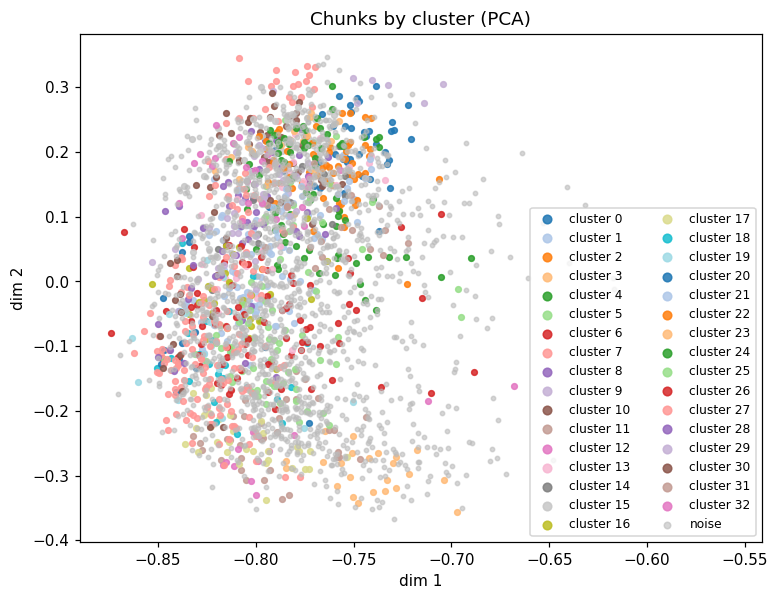

In [7]:
# --- scatter, colored by cluster ---

cmap = plt.get_cmap("tab20")

cluster_colors = {lbl: cmap(lbl % 20) for lbl in present}

noise_color = "#bbbbbb"



def scatter(coords, title):

    fig, ax = plt.subplots(figsize=(8, 6))

    for lbl in present:

        mask = labels == lbl

        ax.scatter(coords[mask, 0], coords[mask, 1], s=14, c=[cluster_colors[lbl]], label=f"cluster {lbl}", alpha=0.85)

    noise_mask = labels == -1

    if noise_mask.any():

        ax.scatter(coords[noise_mask, 0], coords[noise_mask, 1], s=8, c=noise_color, label="noise", alpha=0.6)

    ax.set_title(title)

    ax.set_xlabel("dim 1")

    ax.set_ylabel("dim 2")

    ax.legend(fontsize=8, ncol=2, markerscale=1.5, loc="best")

    return fig



scatter(coords, "Chunks by cluster (PCA)")

if coords_tsne is not None:

    scatter(coords_tsne, "Chunks by cluster (t-SNE)")



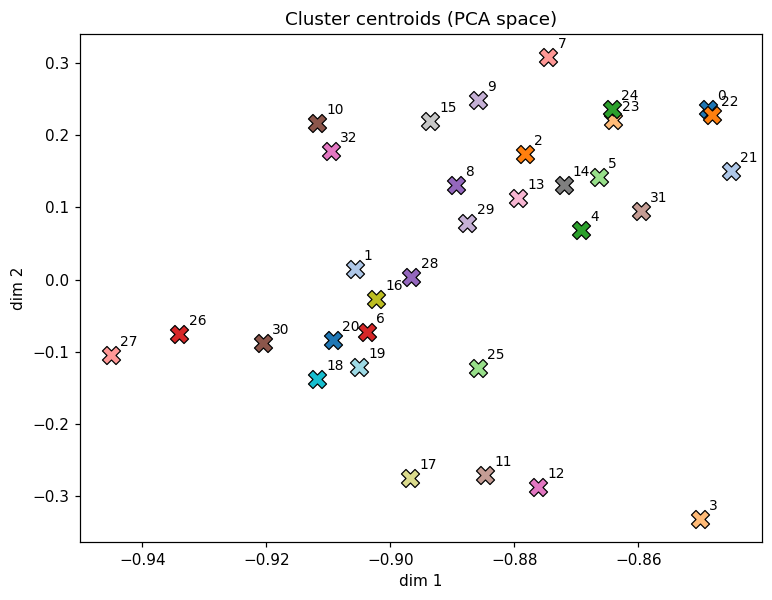

In [8]:
# --- centroids (from the clusters table), projected through the same PCA axes ---
centroid_rows = con.execute(
    "SELECT cluster_index, centroid FROM clusters WHERE worksheet_id = ?", (wid,)
).fetchall()
if centroid_rows:
    centroids = np.array([struct.unpack("<384f", c) for _, c in centroid_rows])
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        c2d = centroids @ vt2.T
    fig, ax = plt.subplots(figsize=(8, 6))
    for (ci, _), (x, y) in zip(centroid_rows, c2d):
        ax.scatter(x, y, s=140, color=cluster_colors.get(int(ci), noise_color),
                   marker="X", edgecolors="black", linewidths=0.8, zorder=5)
        ax.annotate(str(ci), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_title("Cluster centroids (PCA space)")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
else:
    print("no centroid rows in clusters table (legacy worksheet?)")


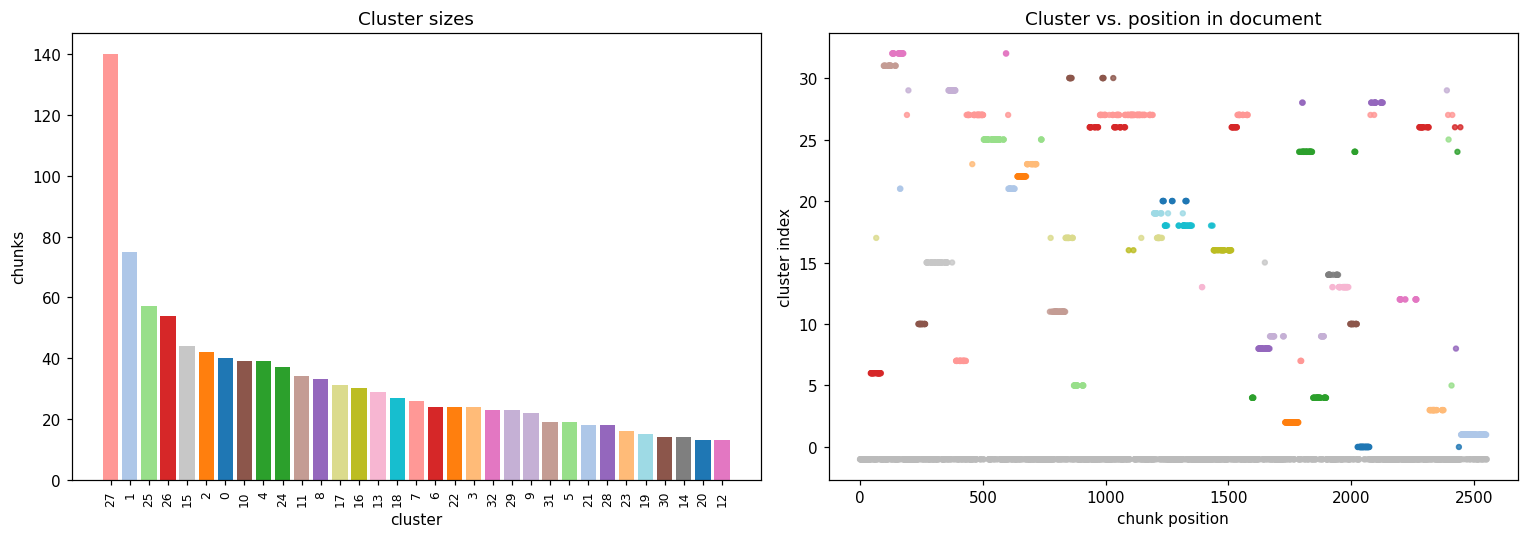

In [9]:
# --- cluster sizes + position layout ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

size_counts = Counter(int(l) for l in labels if l >= 0)
ordered = sorted(size_counts.items(), key=lambda kv: -kv[1])
ax1.bar([str(k) for k, _ in ordered], [v for _, v in ordered], color=[cluster_colors[k] for k, _ in ordered])
ax1.set_title("Cluster sizes")
ax1.set_xlabel("cluster")
ax1.set_ylabel("chunks")
ax1.tick_params(axis="x", labelrotation=90, labelsize=8)

pts = labels.copy()
pts[pts < 0] = -1
hex_colors = [mcolors.to_hex(cluster_colors.get(int(l), noise_color)) for l in pts]
ax2.scatter(positions, pts, s=10, c=hex_colors, alpha=0.8)
ax2.set_title("Cluster vs. position in document")
ax2.set_xlabel("chunk position")
ax2.set_ylabel("cluster index")
plt.tight_layout()


In [10]:
# --- per-cluster drill-down: sample excerpts ---

def clean(text):

    return re.sub(r"\s+", " ", text).strip()



by_label = defaultdict(list)

for i, l in enumerate(labels):

    by_label[int(l)].append(i)



for lbl in sorted(by_label, key=lambda k: -len(by_label[k])):

    idx = by_label[lbl]

    if lbl == -1:

        header = f"NOISE  ({len(idx)} chunks)"

    else:

        header = f"CLUSTER {lbl}  ({len(idx)} chunks, positions {positions[idx].min()}..{positions[idx].max()})"

    print("=" * 70)

    print(header)

    for i in idx[:3]:

        print("   ", clean(texts[i])[:160])



NOISE  (1476 chunks)
    Biology 2e SENIOR CONTRIBUTING AUTHORS MARY ANN CLARK, TEXAS WESLEYAN UNIVERSITY JUNG CHOI, GEORGIA INSTITUTE OF TECHNOLOGY MATTHEW DOUGLAS, GRAND RAPIDS COMMUN
    at https://openstax.org/details/books/ biology-2e.” - If you use this textbook as a bibliographic reference, please include https://openstax.org/details/books/ 
    their courses and meet their educational goals. RICE UNIVERSITY OpenStax, OpenStax CNX, and OpenStax Tutor are initiatives of Rice University. As a leading rese
CLUSTER 27  (140 chunks, positions 191..2411)
    and Chromosomes To understand chromatin, it is helpful to first explore chromosomes, structures within the nucleus that are made up of DNA, the hereditary mater
    that often spreads through a bacterial colony through plasmid exchange from resistant donors to recipient cells. Figure region called the nucleoid. 10.2 Prokary
    3/#eipid1165802978636) This OpenStax book is available for free at http://cnx.org/content/col24361/1.8 C

In [11]:
# --- distinctive keywords per cluster ---

STOPWORDS = set("""a an the and or but of in on at to for with from by is are was were be been

                it its this that these those as not no yes if then than so such can could

                will would should may might must do does did have has had www http https com

                org net page figure fig table """.split())



def tokens(text):

    return [w for w in re.findall(r"[a-zA-Z0-9]{3,}", text.lower()) if w not in STOPWORDS]



global_counts = Counter()

for t in texts:

    global_counts.update(tokens(t))

total_global = sum(global_counts.values())



for lbl in sorted(by_label, key=lambda k: -len(by_label[k])):

    if lbl == -1 or len(by_label[lbl]) < 3:

        continue

    members = by_label[lbl]

    local = Counter()

    for i in members:

        local.update(tokens(texts[i]))

    total_local = sum(local.values())

    def score(w):

        tf = local[w] / total_local if total_local else 0.0

        gf = global_counts[w] / total_global if total_global else 1.0

        return tf * np.log((1.0 + 1e-6) / gf)

    top = sorted(local, key=score, reverse=True)[:8]

    print(f"cluster {lbl:>2} keywords: {', '.join(top)}")



cluster 27 keywords: plants, cell, meiosis, cells, haploid, chromosomes, which, diploid
cluster  1 keywords: 895, 726, 1215, 1245, 999, 1173, 583, 1172
cluster 25 keywords: mendel, alleles, genes, offspring, cross, dominant, chromosome, pea
cluster 26 keywords: soil, nitrogen, fungi, energy, ecosystem, organisms, food, organic
cluster 15 keywords: energy, atp, molecules, molecule, glucose, reactions, phosphate, step
cluster  2 keywords: sensory, receptors, hair, ear, receptor, sound, olfactory, cells
cluster  0 keywords: immune, cells, response, antigen, system, cell, antibodies, mhc
cluster 10 keywords: renal, membrane, transport, water, concentration, cell, into, gradient
cluster  4 keywords: bone, bones, tissue, joints, joint, movement, cartilage, connective
cluster 24 keywords: hormone, hormones, blood, pituitary, thyroid, levels, gland, release
cluster 11 keywords: population, selection, species, speciation, individuals, genetic, evolution, allele
cluster  8 keywords: food, digest